# Flame Optimization Analysis

This notebook analyzes the results of sequence optimization runs targeting
chromatin stripe (flame) features. Flames are asymmetric contact patterns
emanating from a single anchor — typically a strong, unidirectional CTCF site —
and appear as vertical or horizontal streaks in Hi-C contact maps.

Ledidi was run on a set of genomic windows to increase the predicted flame score
(Q3 signal strength, as measured by Akita V2)
across four target intensity levels.

**Structure of this notebook:**
1. Load and preprocess optimization results across all targets and folds    
2. Compare flame scores before/after optimization against natural stripe strengths    
3. Examine how CTCF binding site counts change during optimization    
4. Characterize CTCF orientation patterns in successfully optimized sequences    

In [1]:
import os
import sys

import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath("/home1/smaruj/akita_semifreddo/"))

from utils.df_utils import load_optimization_results, summarize_by_target

## 1. Configuration

- **`BASE_DIR`**: Root directory containing per-target optimization result subdirectories.   
- **`PLOTS_DIR`**: Output directory for saved figures.    
- **`NATURAL_FLAMES_PATH`**: TSV file with Q3 strength scores for natural chromatin stripes in mouse (mm10), used as a biological reference.
- **`RESULT_DIRS`** / **`TARGETS`**: Four flame intensity conditions, corresponding to target Q3 scores of 0.4, 0.6, 0.8, and 1.0. Directory names encode the target value with `p` replacing the decimal point (e.g. `flame_pos0p6` → target 0.6).   
- **`FOLDS`**: Eight cross-validation folds from the Akita v2 model.    

In [2]:
BASE_DIR  = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/flames/results/")
PLOTS_DIR = Path("./../plots/")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

NATURAL_FLAMES_PATH = Path("/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/analysis/natural_features/flames/mouse_selected_stripes_strength.tsv")

RESULT_DIRS = ["flame_pos0p4", "flame_pos0p6", "flame_pos0p8", "flame_pos1p0"]
TARGETS     = [0.4, 0.6, 0.8, 1.0]
FOLDS       = range(8)

## 2. Load and preprocess results

`load_optimization_results` walks each result directory, parses per-fold TSV files, and concatenates them into a single DataFrame.

Derived columns:
- **`flame_diff`**: Change in flame score (edited − original); positive values indicate the optimization moved the sequence toward a stronger stripe.    
- **`optimization_success`**: Boolean flag — `True` if `flame_diff > 0`.

In [3]:
df = load_optimization_results(RESULT_DIRS, BASE_DIR, FOLDS)

df["flame_diff"]     = df["flame3_edited"] - df["flame3_orig"]
df["optimization_success"] = df["flame_diff"] > 0

print(f"Loaded {len(df)} windows across {df['fold'].nunique()} folds and {df['target'].nunique()} targets")
print(f"Successful optimizations: {df['optimization_success'].sum()} / {len(df)} ({100 * df['optimization_success'].mean():.1f}%)")

Loaded 1420 windows across 8 folds and 4 targets
Successful optimizations: 1305 / 1420 (91.9%)


## 3. Summary statistics by target intensity

In [4]:
summary = summarize_by_target(df)
summary

,target,n_total,n_no_edits,n_no_depletion,success_rate_pct,mean_n_edits,mean_last_step
0,0.4,355,44,0,87.6,38.1,1963.8
1,0.6,355,22,0,93.8,44.3,1961.0
2,0.8,355,26,0,92.7,55.7,1949.7
3,1.0,355,23,0,93.5,63.3,1952.2


## 4. Flame score distributions: before vs. after optimization vs. natural stripes

Box plots compare flame scores (Q3 predicted signal) across four groups:    
- **Before optimization**: original scores for the successfully optimized windows (sampled once using `TARGETS[0]`, to avoid duplicating the same windows across targets).    
- **Target N**: edited scores for each intensity condition.    
- **Natural flames**: scores from the reference set of natural stripes, providing a biological reference for the range of achievable signal.

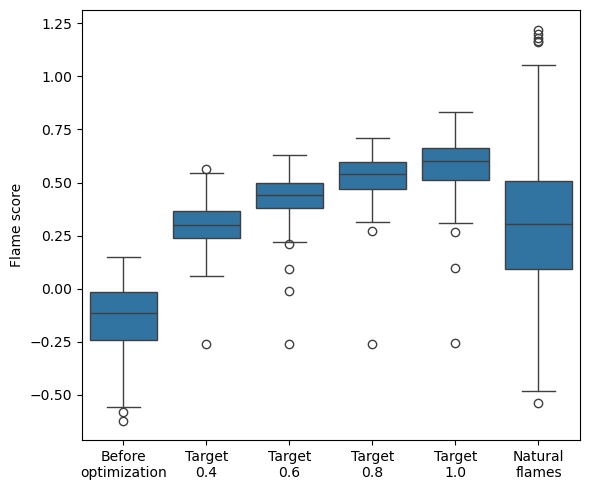

In [6]:
nat_df = pd.read_csv(NATURAL_FLAMES_PATH, sep="\t")

successful = df[df["optimization_success"]]

parts = []

# (1) Original insulation scores — one target only to avoid duplicate windows
orig_scores = successful[successful["target"] == TARGETS[0]][["flame3_orig"]].copy()
orig_scores["group"] = "Before\noptimization"
orig_scores = orig_scores.rename(columns={"flame3_orig": "flame_score"})
parts.append(orig_scores)

# (2) Edited insulation scores per target
for target in TARGETS:
    edited = successful[successful["target"] == target][["flame3_edited"]].copy()
    edited["group"] = f"Target\n{target}"
    edited = edited.rename(columns={"flame3_edited": "flame_score"})
    parts.append(edited)

# (3) Natural boundary insulation scores
nat_scores = nat_df[["flame_strength_q3"]].copy()
nat_scores["group"] = "Natural\nflames"
nat_scores = nat_scores.rename(columns={"flame_strength_q3": "flame_score"})
parts.append(nat_scores)

plot_df = pd.concat(parts, ignore_index=True)
group_order = ["Before\noptimization"] + [f"Target\n{t}" for t in TARGETS] + ["Natural\nflames"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=plot_df, x="group", y="flame_score", order=group_order, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Flame score")

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "flame_scores_boxplot.svg", format="svg")
plt.show()

## 5. CTCF binding site counts before and after optimization

Chromatin stripes are thought to arise when a strong CTCF anchor stalls
loop extrusion asymmetrically, producing a one-sided contact pattern.
This section checks whether the optimizer increases the number of predicted
CTCF binding sites as a strategy to strengthen the flame feature.

The "before optimization" group is again sampled from a single target to
avoid counting the same windows multiple times.


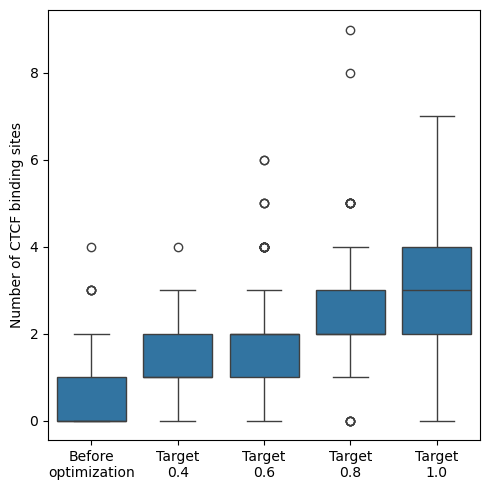

In [8]:
parts = []

# (1) Initial CTCF counts — one target only to avoid duplicate windows
orig_ctcf = successful[successful["target"] == TARGETS[0]][["init_CTCFs_num"]].copy()
orig_ctcf["group"] = "Before\noptimization"
orig_ctcf = orig_ctcf.rename(columns={"init_CTCFs_num": "n_CTCFs"})
parts.append(orig_ctcf)

# (2) Edited CTCF counts per target
for target in TARGETS:
    edited = successful[successful["target"] == target][["CTCFs_num"]].copy()
    edited["group"] = f"Target\n{target}"
    edited = edited.rename(columns={"CTCFs_num": "n_CTCFs"})
    parts.append(edited)

plot_df = pd.concat(parts, ignore_index=True)
group_order = ["Before\noptimization"] + [f"Target\n{t}" for t in TARGETS]

fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=plot_df, x="group", y="n_CTCFs", order=group_order, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Number of CTCF binding sites")

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "ctcf_counts_boxplot.svg", format="svg")
plt.show()

## 6. CTCF orientation patterns in successfully optimized sequences

Unlike loop dots — which require a convergent CTCF pair — stripes are
associated with a single strong, directional CTCF anchor. The orientation
string recorded for each window encodes the full combination of `+`/`−`
motifs present after optimization (e.g. `"+-"`, `"+"`, `"--+"`).

Here we plot the frequency of each observed orientation string in
successfully optimized sequences, filtering out:
- Windows with **no CTCF** (`"no"`), which represent optimization failures from a motif-placement perspective.
- Rare orientation combinations with **≤ 10 occurrences**, to focus on the predominant patterns.

A strong enrichment for single-orientation strings (all `+` or all `−`)
would be consistent with the asymmetric, unidirectional model of stripe formation.

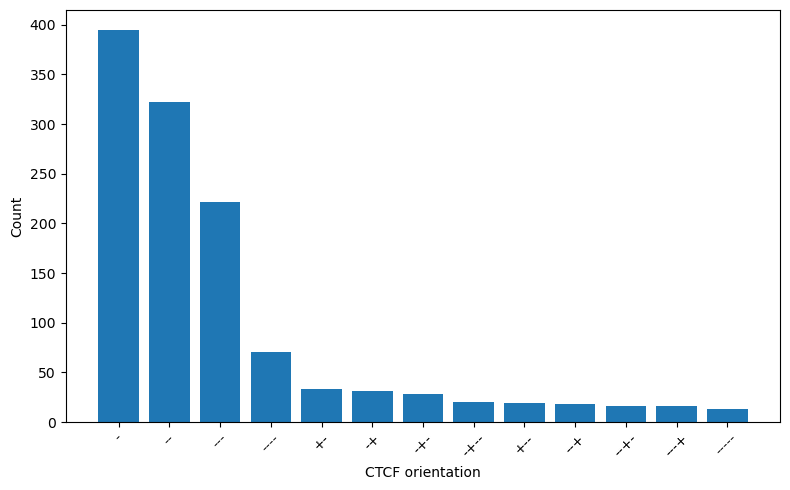

In [10]:
orientation_counts = successful["orientation"].value_counts()

orientation_counts = (
    orientation_counts
    .drop("no", errors="ignore")
    .loc[lambda x: x > 10]
    .sort_values(ascending=False)
)

orientation_counts = orientation_counts[orientation_counts > 10].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(orientation_counts.index, orientation_counts.values)
ax.set_xlabel("CTCF orientation")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
# plt.savefig(PLOTS_DIR / "ctcf_orientation_histogram.svg", format="svg")
plt.show()